Install packages and stuff

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                  LogisticRegression, RidgeCV, LassoCV, ElasticNetCV)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              roc_auc_score, average_precision_score,
                              f1_score, brier_score_loss, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb
%pip install shap
import shap


warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 150, "axes.titlesize": 13})
FIG_DPI = 150



Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


/Users/shikh/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load Data

In [2]:
CSV_PATH = "/Users/shikh/Downloads/HW Winter 26/ig_datasets/instagram_usage_lifestyle.csv"

df = pd.read_csv(CSV_PATH, low_memory=False)
print(f"    Loaded from CSV: {df.shape}")

    Loaded from CSV: (1547896, 58)


Feature Engineering & Preprocessing

In [3]:
# Ordinal encoding
income_map = {"Low":1,"Lower-Middle":2,"Middle":3,"Upper-Middle":4,"High":5}
edu_map    = {"No Formal Education":1,"High School":2,"Some College":3,
              "Bachelor's":4,"Master's":5,"PhD":6,"Other":3}
for col, mapping in [("income_level", income_map), ("education_level", edu_map)]:
    if col in df.columns:
        df[f"{col}_num"] = df[col].map(mapping).fillna(3).astype(int)

# Binary demographics
if "gender" in df.columns:
    df["female"]    = (df["gender"] == "Female").astype(int)
    df["nonbinary"] = (df["gender"] == "Non-binary").astype(int)
if "urban_rural" in df.columns:
    df["urban"]    = (df["urban_rural"] == "Urban").astype(int)
    df["suburban"] = (df["urban_rural"] == "Suburban").astype(int)

# Passive / Active composite indices
from sklearn.preprocessing import StandardScaler as SS
IG_PASSIVE = [c for c in ["reels_watched_per_day","stories_viewed_per_day",
                           "time_on_feed_per_day","time_on_explore_per_day",
                           "ads_viewed_per_day"] if c in df.columns]
IG_ACTIVE  = [c for c in ["posts_created_per_week","comments_written_per_day",
                           "dms_sent_per_week","likes_given_per_day"] if c in df.columns]

valid_idx = df[IG_PASSIVE + IG_ACTIVE].dropna().index
sc_p = SS(); sc_a = SS()
df.loc[valid_idx, "passive_index"] = sc_p.fit_transform(
    df.loc[valid_idx, IG_PASSIVE]).mean(axis=1)
df.loc[valid_idx, "active_index"] = sc_a.fit_transform(
    df.loc[valid_idx, IG_ACTIVE]).mean(axis=1)

# Log transforms for skewed features
for col in ["followers_count","following_count","reels_watched_per_day"]:
    if col in df.columns:
        df[f"log_{col}"] = np.log1p(df[col].clip(lower=0))

# High stress binary (>=75th pct = 30)
if "high_stress_binary" not in df.columns:
    df["high_stress_binary"] = (df["perceived_stress_score"] >= 30).astype(int)

# Age group
if "age_group" not in df.columns:
    df["age_group"] = pd.cut(df["age"], bins=[13,18,25,35,45,55,100],
        labels=["13-18","19-25","26-35","36-45","46-55","55+"])

In [4]:
#ft set for modeling
FEATURE_COLS = [c for c in [
    # Demographics
    "age","female","nonbinary","urban","suburban","income_level_num","education_level_num",
    # Instagram composites
    "passive_index","active_index",
    # Instagram individual features (non-collinear subset)
    "sessions_per_day","average_session_length_minutes","notification_response_rate",
    "log_followers_count","log_following_count","user_engagement_score",
    "ads_clicked_per_day","posts_created_per_week",
    # Lifestyle
    "exercise_hours_per_week","sleep_hours_per_night","hobbies_count",
    "weekly_work_hours","social_events_per_month","books_read_per_year",
    "daily_steps_count","body_mass_index",
] if c in df.columns]

TARGETS = {
    "perceived_stress_score":          "regression",
    "self_reported_happiness":         "regression",
    "daily_active_minutes_instagram":  "regression",
}
CLF_TARGET = "high_stress_binary"

print(f"    Feature columns: {len(FEATURE_COLS)}")
print(f"    Features: {FEATURE_COLS}")

    Feature columns: 25
    Features: ['age', 'female', 'nonbinary', 'urban', 'suburban', 'income_level_num', 'education_level_num', 'passive_index', 'active_index', 'sessions_per_day', 'average_session_length_minutes', 'notification_response_rate', 'log_followers_count', 'log_following_count', 'user_engagement_score', 'ads_clicked_per_day', 'posts_created_per_week', 'exercise_hours_per_week', 'sleep_hours_per_night', 'hobbies_count', 'weekly_work_hours', 'social_events_per_month', 'books_read_per_year', 'daily_steps_count', 'body_mass_index']


Train/ Validation/ Test Split: 70-15-15

In [5]:
SAMPLE_N = 300_000
df_model = df[FEATURE_COLS + list(TARGETS.keys()) + [CLF_TARGET]].dropna()
df_model = df_model.sample(min(SAMPLE_N, len(df_model)), random_state=42).reset_index(drop=True)
print(f"    Modeling dataset: {len(df_model):,} rows x {len(FEATURE_COLS)} features")

# Split
idx_train, idx_temp = train_test_split(df_model.index, test_size=0.30, random_state=42)
idx_val,   idx_test = train_test_split(idx_temp,        test_size=0.50, random_state=42)

X_train = df_model.loc[idx_train, FEATURE_COLS]
X_val   = df_model.loc[idx_val,   FEATURE_COLS]
X_test  = df_model.loc[idx_test,  FEATURE_COLS]
print(f"    Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

# Scale for linear models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

    Modeling dataset: 300,000 rows x 25 features
    Train: 210,000 | Val: 45,000 | Test: 45,000


Regression Benchmark

In [6]:
all_reg_results = {}

for target in TARGETS:
    print(f"\n  --- Target: {target} ---")
    y_train = df_model.loc[idx_train, target].values
    y_val   = df_model.loc[idx_val,   target].values
    y_test  = df_model.loc[idx_test,  target].values

    results = {}

#ols
    t0 = time.time()
    ols = LinearRegression()
    ols.fit(X_train_sc, y_train)
    pred = ols.predict(X_test_sc)
    results["OLS"] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE":  mean_absolute_error(y_test, pred),
        "R2":   r2_score(y_test, pred),
        "time": time.time() - t0
    }
    print(f"    OLS      RMSE={results['OLS']['RMSE']:.4f}  R²={results['OLS']['R2']:.4f}")

#ridge
    t0 = time.time()
    alphas = np.logspace(-3, 4, 30)
    ridge_cv = RidgeCV(alphas=alphas, cv=5)
    ridge_cv.fit(X_train_sc, y_train)
    pred = ridge_cv.predict(X_test_sc)
    results["Ridge"] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE":  mean_absolute_error(y_test, pred),
        "R2":   r2_score(y_test, pred),
        "alpha": ridge_cv.alpha_,
        "time": time.time() - t0
    }
    print(f"    Ridge    RMSE={results['Ridge']['RMSE']:.4f}  R²={results['Ridge']['R2']:.4f}  alpha={ridge_cv.alpha_:.4f}")

#LASSO 
    t0 = time.time()
    lasso_cv = LassoCV(cv=5, max_iter=5000, random_state=42, n_jobs=-1)
    lasso_cv.fit(X_train_sc, y_train)
    pred = lasso_cv.predict(X_test_sc)
    n_zero = np.sum(np.abs(lasso_cv.coef_) < 1e-6)
    results["LASSO"] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE":  mean_absolute_error(y_test, pred),
        "R2":   r2_score(y_test, pred),
        "alpha": lasso_cv.alpha_,
        "n_zero_coefs": int(n_zero),
        "time": time.time() - t0
    }
    print(f"    LASSO    RMSE={results['LASSO']['RMSE']:.4f}  R²={results['LASSO']['R2']:.4f}  "
          f"zeroed={n_zero}/{len(FEATURE_COLS)}")

#elastic net
    t0 = time.time()
    en_cv = ElasticNetCV(cv=5, max_iter=5000, random_state=42, n_jobs=-1,
                         l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9])
    en_cv.fit(X_train_sc, y_train)
    pred = en_cv.predict(X_test_sc)
    results["ElasticNet"] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE":  mean_absolute_error(y_test, pred),
        "R2":   r2_score(y_test, pred),
        "alpha": en_cv.alpha_,
        "l1_ratio": en_cv.l1_ratio_,
        "time": time.time() - t0
    }
    print(f"    ElasticNet RMSE={results['ElasticNet']['RMSE']:.4f}  R²={results['ElasticNet']['R2']:.4f}")

#random forest
    t0 = time.time()
    rf = RandomForestRegressor(n_estimators=300, max_features="sqrt",
                               min_samples_leaf=5, n_jobs=-1, random_state=42)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    results["RandomForest"] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE":  mean_absolute_error(y_test, pred),
        "R2":   r2_score(y_test, pred),
        "time": time.time() - t0
    }
    print(f"    RF       RMSE={results['RandomForest']['RMSE']:.4f}  R²={results['RandomForest']['R2']:.4f}")

# xgboost
    t0 = time.time()
    xgb_mod = xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=5, reg_lambda=1.0,
        eval_metric="rmse", early_stopping_rounds=20,
        random_state=42, n_jobs=-1, verbosity=0
    )
    xgb_mod.fit(X_train, y_train,
                eval_set=[(X_val, y_val)], verbose=False)
    pred = xgb_mod.predict(X_test)
    results["XGBoost"] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE":  mean_absolute_error(y_test, pred),
        "R2":   r2_score(y_test, pred),
        "best_iter": xgb_mod.best_iteration,
        "time": time.time() - t0
    }
    print(f"    XGBoost  RMSE={results['XGBoost']['RMSE']:.4f}  R²={results['XGBoost']['R2']:.4f}  "
          f"iters={xgb_mod.best_iteration}")
    
# light gbm
    t0 = time.time()
    lgb_train = lgb.Dataset(X_train, label=y_train)
    lgb_val   = lgb.Dataset(X_val,   label=y_val, reference=lgb_train)
    lgb_params = {
        "objective": "regression", "metric": "rmse",
        "learning_rate": 0.05, "num_leaves": 63,
        "max_depth": -1, "min_data_in_leaf": 20,
        "feature_fraction": 0.8, "bagging_fraction": 0.8,
        "bagging_freq": 5, "lambda_l2": 1.0,
        "verbose": -1, "n_jobs": -1, "seed": 42
    }
    callbacks = [lgb.early_stopping(20, verbose=False), lgb.log_evaluation(-1)]
    lgb_mod = lgb.train(lgb_params, lgb_train, num_boost_round=500,
                        valid_sets=[lgb_val], callbacks=callbacks)
    pred = lgb_mod.predict(X_test)
    results["LightGBM"] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE":  mean_absolute_error(y_test, pred),
        "R2":   r2_score(y_test, pred),
        "best_iter": lgb_mod.best_iteration,
        "time": time.time() - t0
    }
    print(f"    LightGBM RMSE={results['LightGBM']['RMSE']:.4f}  R²={results['LightGBM']['R2']:.4f}  "
          f"iters={lgb_mod.best_iteration}")

    all_reg_results[target] = results

    # Save model results table
    tbl = pd.DataFrame({m: {k: v for k, v in d.items() if k in ["RMSE","MAE","R2"]}
                        for m, d in results.items()}).T.round(5)


  --- Target: perceived_stress_score ---
    OLS      RMSE=6.2792  R²=0.7195
    Ridge    RMSE=6.2792  R²=0.7195  alpha=12.6896
    LASSO    RMSE=6.2790  R²=0.7195  zeroed=9/25
    ElasticNet RMSE=6.2791  R²=0.7195
    RF       RMSE=6.1211  R²=0.7334
    XGBoost  RMSE=6.0938  R²=0.7358  iters=365
    LightGBM RMSE=6.0987  R²=0.7354  iters=195

  --- Target: self_reported_happiness ---
    OLS      RMSE=2.6493  R²=0.1502
    Ridge    RMSE=2.6493  R²=0.1502  alpha=67.2336
    LASSO    RMSE=2.6493  R²=0.1502  zeroed=0/25
    ElasticNet RMSE=2.6493  R²=0.1502
    RF       RMSE=2.6337  R²=0.1602
    XGBoost  RMSE=2.6294  R²=0.1629  iters=106
    LightGBM RMSE=2.6293  R²=0.1630  iters=131

  --- Target: daily_active_minutes_instagram ---
    OLS      RMSE=14.7262  R²=0.9822
    Ridge    RMSE=14.7262  R²=0.9822  alpha=0.4520
    LASSO    RMSE=14.7381  R²=0.9822  zeroed=17/25
    ElasticNet RMSE=14.8511  R²=0.9819
    RF       RMSE=10.1180  R²=0.9916
    XGBoost  RMSE=6.2898  R²=0.9968  iters

                  RMSE       MAE       R2
OLS           14.72620  11.27357  0.98223
Ridge         14.72620  11.27356  0.98223
LASSO         14.73807  11.26500  0.98221
ElasticNet    14.85108  11.31582  0.98193
RandomForest  10.11802   7.02170  0.99161
XGBoost        6.28982   4.65539  0.99676
LightGBM       5.16263   3.77822  0.99782

    Generating model comparison figures ...
                            target         model     RMSE      MAE      R2
0           perceived_stress_score           OLS   6.2792   5.0537  0.7195
1           perceived_stress_score         Ridge   6.2792   5.0537  0.7195
2           perceived_stress_score         LASSO   6.2790   5.0536  0.7195
3           perceived_stress_score    ElasticNet   6.2791   5.0538  0.7195
4           perceived_stress_score  RandomForest   6.1211   4.9151  0.7334
5           perceived_stress_score       XGBoost   6.0938   4.8800  0.7358
6           perceived_stress_score      LightGBM   6.0987   4.8852  0.7354
7          self_rep

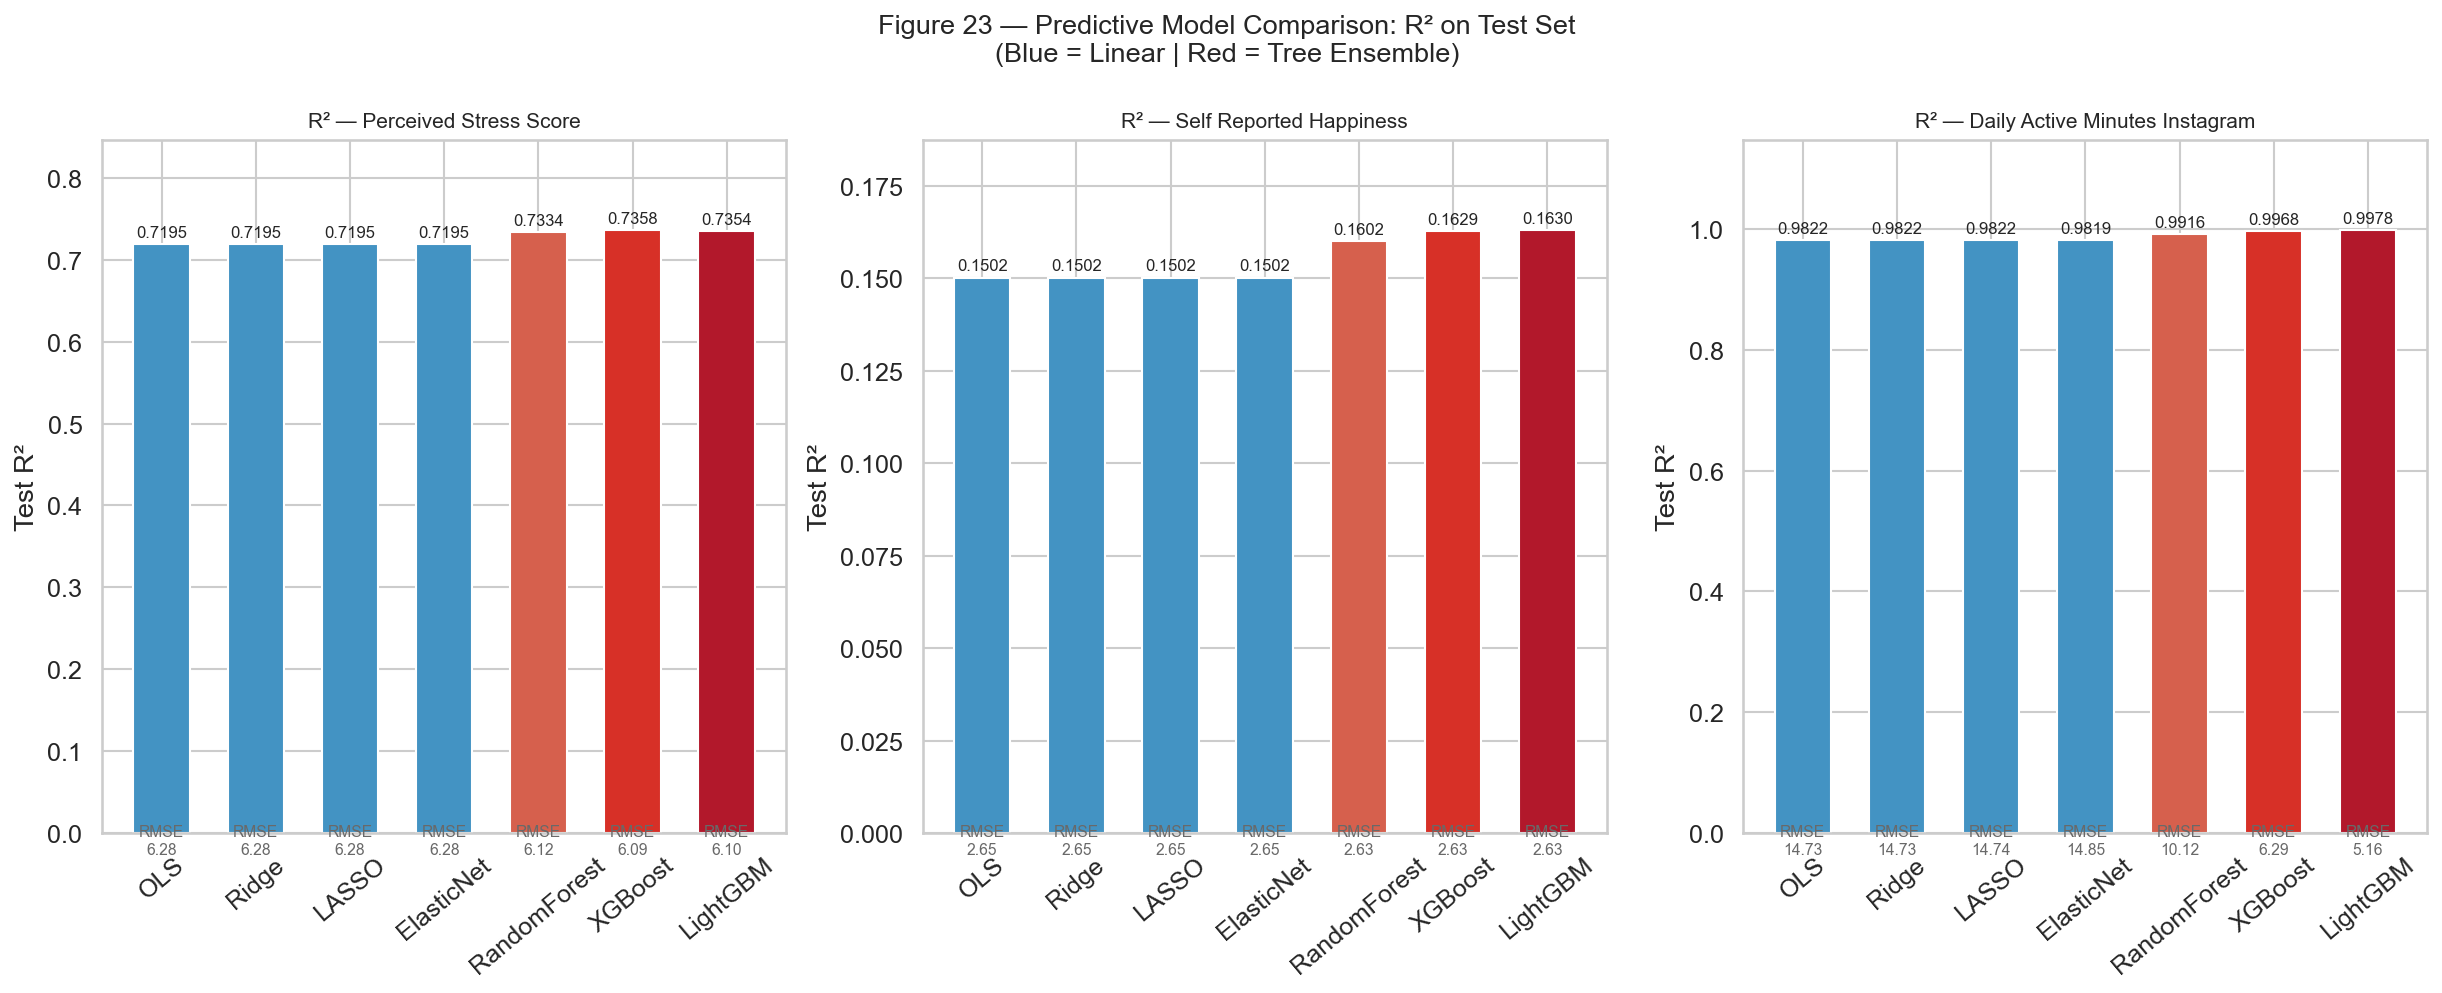

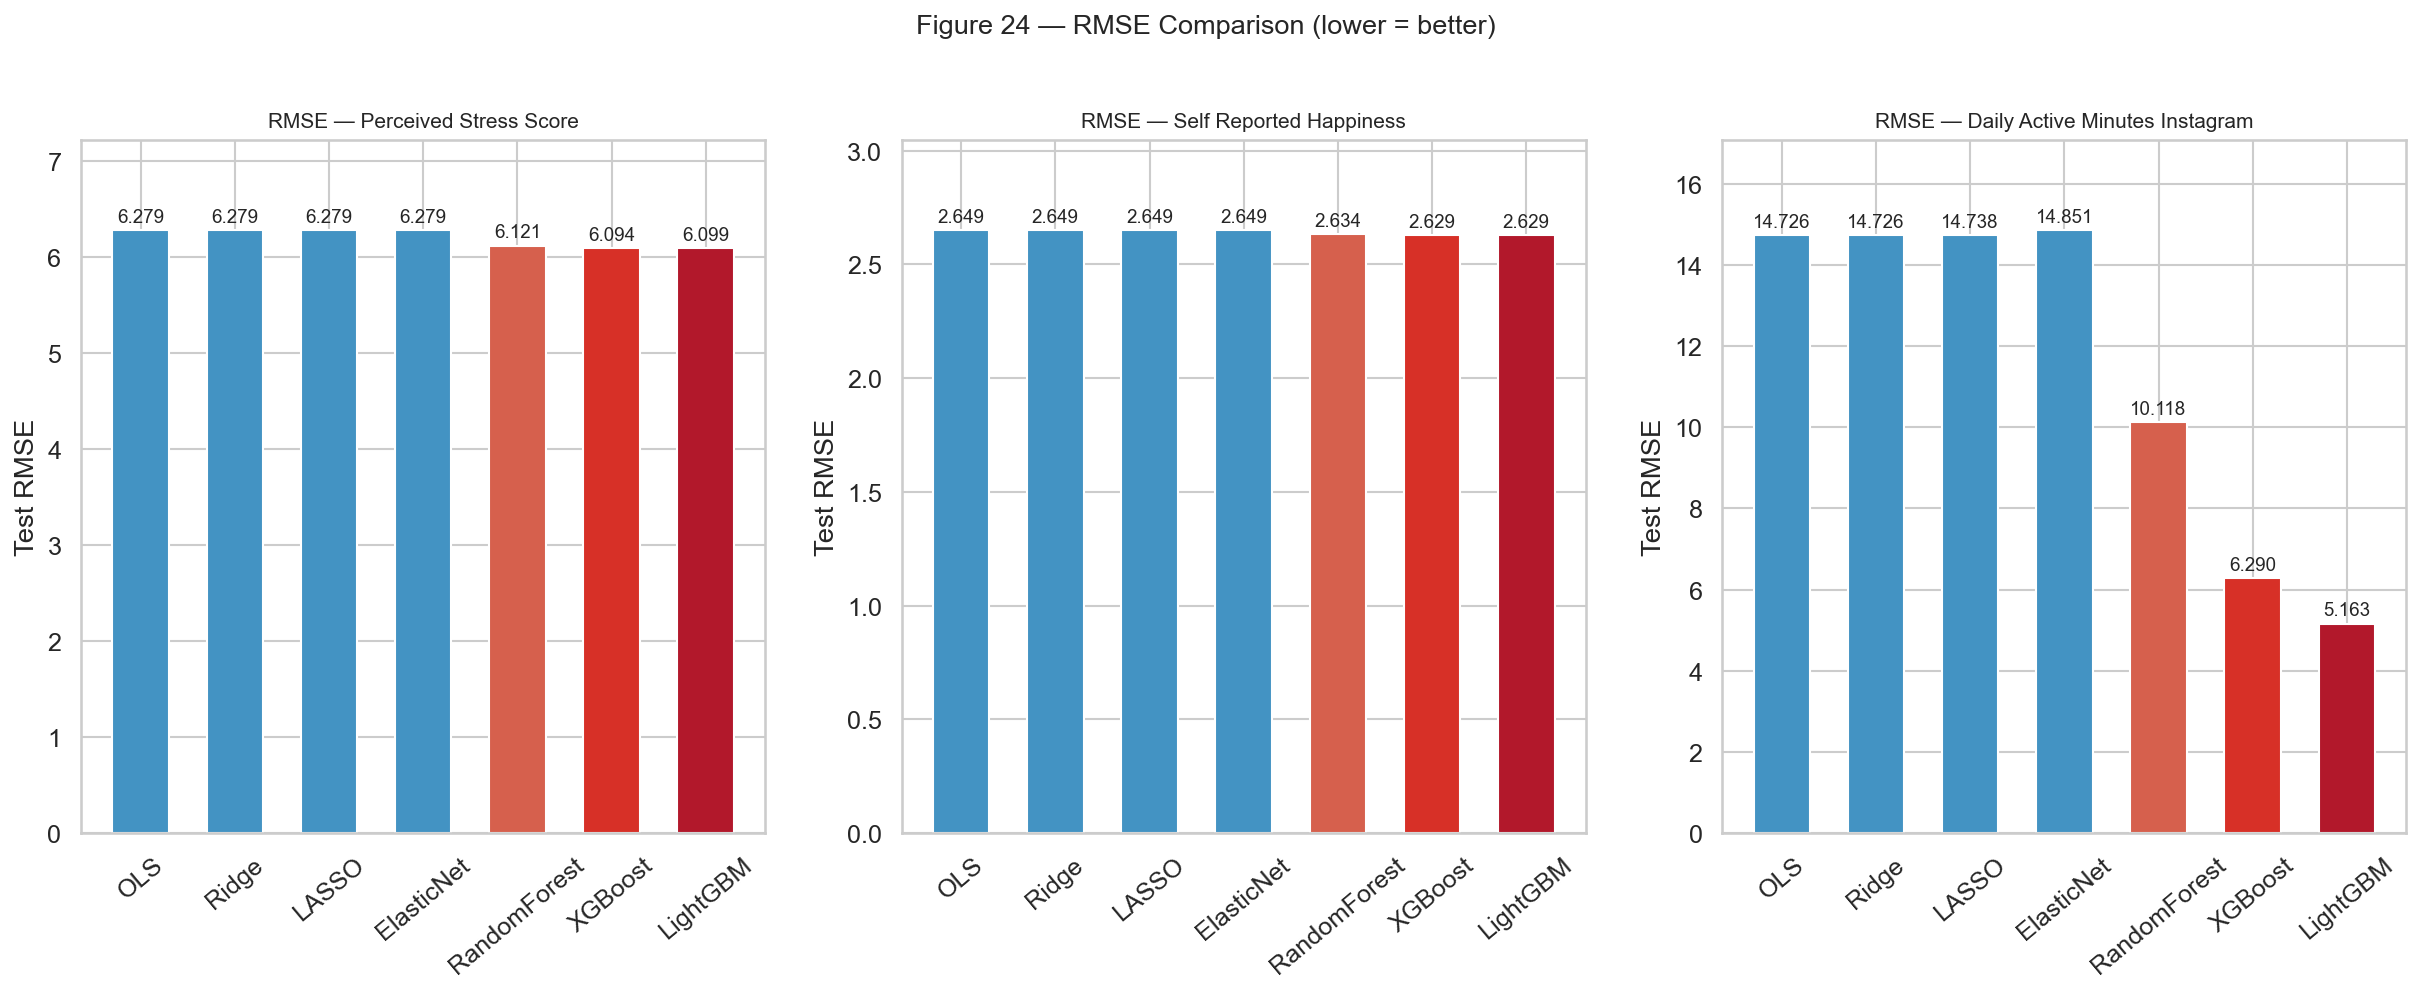

In [7]:
print(tbl)

print("\n    Generating model comparison figures ...")
MODELS  = ["OLS","Ridge","LASSO","ElasticNet","RandomForest", "XGBoost","LightGBM"] 
COLORS  = ["#4393c3","#4393c3","#4393c3","#4393c3","#d6604d","#d73027","#b2182b"]

# consolidated r2 comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, target in zip(axes, list(TARGETS.keys())):
    r2s   = [all_reg_results[target][m]["R2"]   for m in MODELS]
    rmses = [all_reg_results[target][m]["RMSE"]  for m in MODELS]
    bars = ax.bar(MODELS, r2s, color=COLORS, edgecolor="white", width=0.6)
    ax.bar_label(bars, fmt="%.4f", padding=2, fontsize=8, rotation=0)
    ax.set_ylim(0, max(r2s)*1.15)
    ax.set_title(f"R² — {target.replace('_',' ').title()}", fontsize=10)
    ax.set_ylabel("Test R²")
    ax.tick_params(axis="x", rotation=40)
    for i, (m, rmse) in enumerate(zip(MODELS, rmses)):
        ax.text(i, -0.03, f"RMSE\n{rmse:.2f}", ha="center", fontsize=7.5,
                color="dimgray", transform=ax.get_xaxis_transform())

plt.suptitle("Figure 23 — Predictive Model Comparison: R² on Test Set\n"
             "(Blue = Linear | Red = Tree Ensemble)", fontsize=13, y=1.02)

#rmse comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, target in zip(axes, list(TARGETS.keys())):
    rmses = [all_reg_results[target][m]["RMSE"] for m in MODELS]
    bars  = ax.bar(MODELS, rmses, color=COLORS, edgecolor="white", width=0.6)
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=9)
    ax.set_ylim(0, max(rmses)*1.15)
    ax.set_title(f"RMSE — {target.replace('_',' ').title()}", fontsize=10)
    ax.set_ylabel("Test RMSE")
    ax.tick_params(axis="x", rotation=40)

plt.suptitle("Figure 24 — RMSE Comparison (lower = better)", fontsize=13, y=1.02)

#full benchmark table

rows = []
for target in TARGETS:
    for model in MODELS:
        d = all_reg_results[target][model]
        rows.append({
            "target": target, "model": model,
            "RMSE": round(d["RMSE"], 4),
            "MAE":  round(d["MAE"],  4),
            "R2":   round(d["R2"],   4),
        })
bench_df = pd.DataFrame(rows)
# bench_df.to_csv(os.path.join(OUT_DIR, "table1_full_benchmark.csv"), index=False)
# print(f"\n    Full benchmark table saved.")
print(bench_df)
print(bench_df.pivot(index="model", columns="target", values="R2").round(4).to_string())


Classification, high stress binary

    Positive class rate (train): 26.8%


/Users/shikh/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shikh/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shikh/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shikh/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/shikh/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_s

    LogisticReg  AUC=0.9290  AP=0.8203
    RF           AUC=0.9281  AP=0.8169
    XGBoost      AUC=0.9293  AP=0.8217
    LightGBM     AUC=0.9291  AP=0.8206
                  AUC       AP       F1    Brier
LogisticReg   0.92898  0.82033  0.73294  0.09568
RandomForest  0.92807  0.81688  0.73011  0.09611
XGBoost       0.92930  0.82174  0.73132  0.09527
LightGBM      0.92913  0.82062  0.73388  0.09540

    Best classifier: XGBoost


Text(0.5, 1.0, 'Figure 26 — Confusion Matrix: XGBoost\n(High-Stress Classification)')

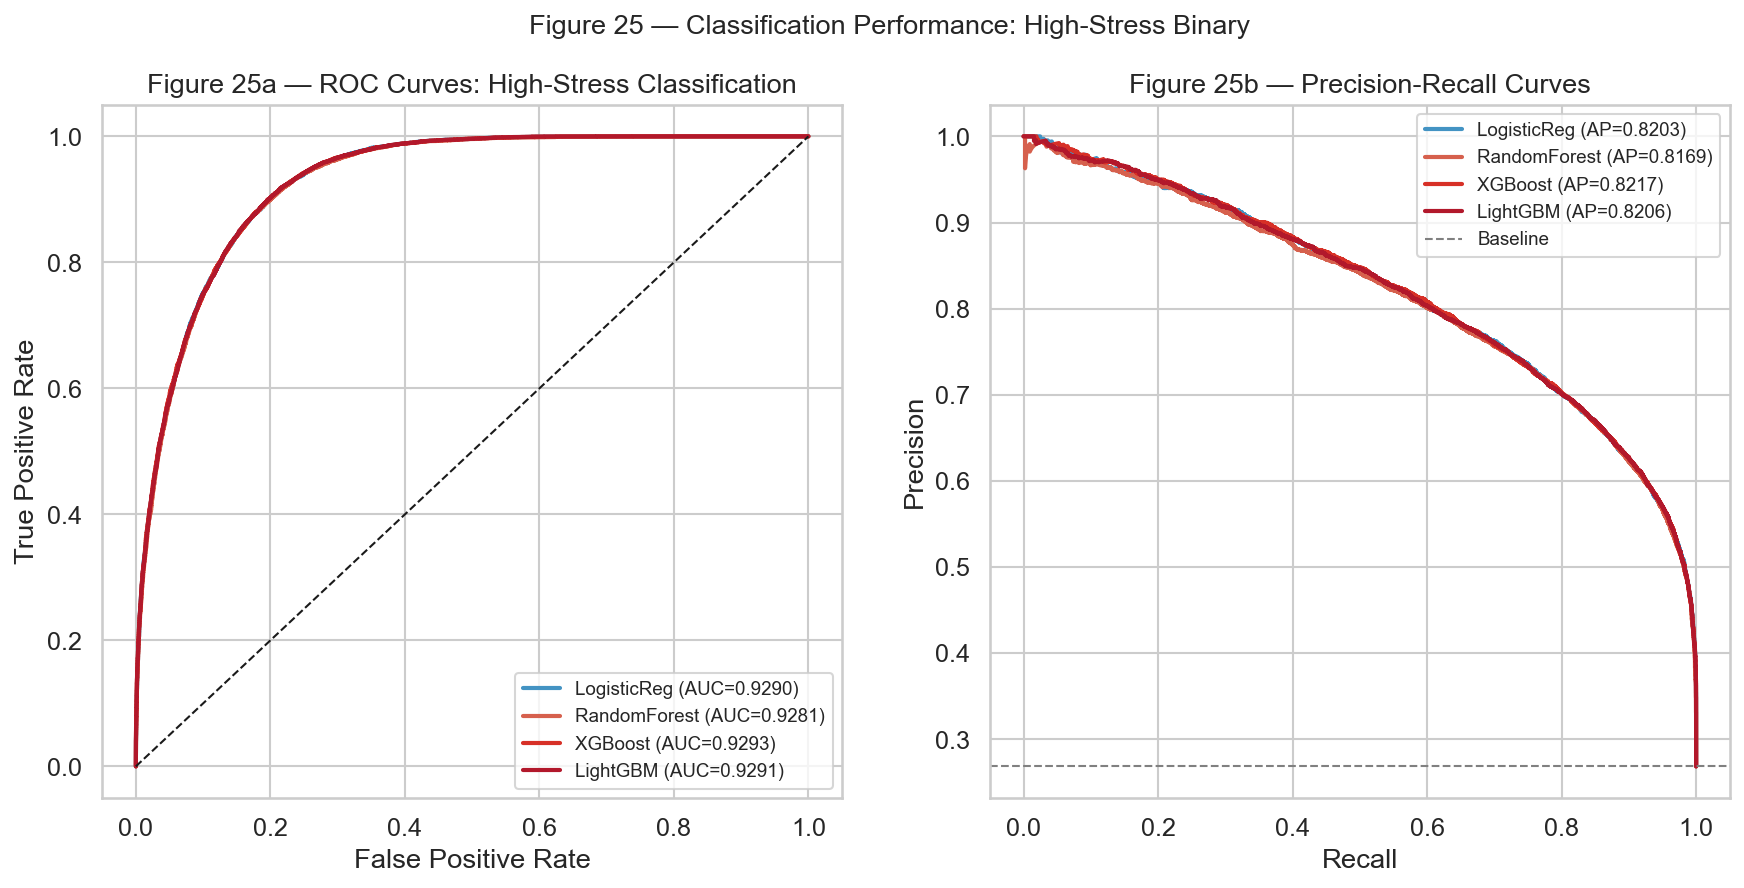

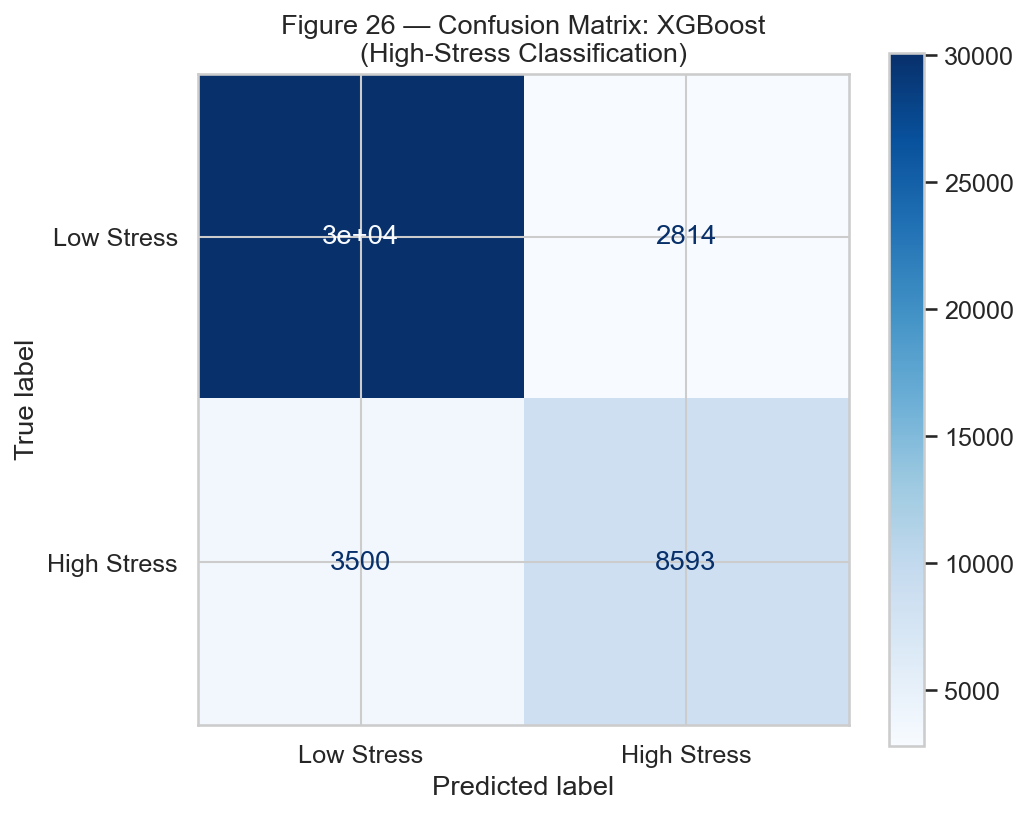

In [8]:
y_train_c = df_model.loc[idx_train, CLF_TARGET].values
y_val_c   = df_model.loc[idx_val,   CLF_TARGET].values
y_test_c  = df_model.loc[idx_test,  CLF_TARGET].values
print(f"    Positive class rate (train): {y_train_c.mean()*100:.1f}%")

clf_results = {}

# Logistic Regression
t0 = time.time()
lr = LogisticRegression(C=1.0, max_iter=500, random_state=42, n_jobs=-1)
lr.fit(X_train_sc, y_train_c)
prob = lr.predict_proba(X_test_sc)[:, 1]
pred_bin = (prob >= 0.5).astype(int)
clf_results["LogisticReg"] = {
    "AUC":  roc_auc_score(y_test_c, prob),
    "AP":   average_precision_score(y_test_c, prob),
    "F1":   f1_score(y_test_c, pred_bin),
    "Brier":brier_score_loss(y_test_c, prob),
    "time": time.time() - t0
}
print(f"    LogisticReg  AUC={clf_results['LogisticReg']['AUC']:.4f}  "
      f"AP={clf_results['LogisticReg']['AP']:.4f}")


# Random Forest Classifier
t0 = time.time()
rfc = RandomForestClassifier(n_estimators=300, max_features="sqrt",
                              min_samples_leaf=5, n_jobs=-1, random_state=42)
rfc.fit(X_train, y_train_c)
prob = rfc.predict_proba(X_test)[:, 1]
pred_bin = (prob >= 0.5).astype(int)
clf_results["RandomForest"] = {
    "AUC":  roc_auc_score(y_test_c, prob),
    "AP":   average_precision_score(y_test_c, prob),
    "F1":   f1_score(y_test_c, pred_bin),
    "Brier":brier_score_loss(y_test_c, prob),
    "time": time.time() - t0
}
print(f"    RF           AUC={clf_results['RandomForest']['AUC']:.4f}  "
      f"AP={clf_results['RandomForest']['AP']:.4f}")
# XGBoost Classifier
t0 = time.time()
xgbc = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=1,
    eval_metric="auc", early_stopping_rounds=20,
    random_state=42, n_jobs=-1, verbosity=0
)
xgbc.fit(X_train, y_train_c, eval_set=[(X_val, y_val_c)], verbose=False)
prob = xgbc.predict_proba(X_test)[:, 1]
pred_bin = (prob >= 0.5).astype(int)
clf_results["XGBoost"] = {
    "AUC":  roc_auc_score(y_test_c, prob),
    "AP":   average_precision_score(y_test_c, prob),
    "F1":   f1_score(y_test_c, pred_bin),
    "Brier":brier_score_loss(y_test_c, prob),
    "time": time.time() - t0
}
print(f"    XGBoost      AUC={clf_results['XGBoost']['AUC']:.4f}  "
      f"AP={clf_results['XGBoost']['AP']:.4f}")

# LightGBM Classifier
t0 = time.time()
lgb_tr = lgb.Dataset(X_train, label=y_train_c)
lgb_vl = lgb.Dataset(X_val,   label=y_val_c, reference=lgb_tr)
lgb_clf_params = {
    "objective":"binary","metric":"auc","learning_rate":0.05,
    "num_leaves":63,"feature_fraction":0.8,"bagging_fraction":0.8,
    "bagging_freq":5,"lambda_l2":1.0,"verbose":-1,"seed":42
}
lgb_clf = lgb.train(lgb_clf_params, lgb_tr, num_boost_round=500,
                    valid_sets=[lgb_vl],
                    callbacks=[lgb.early_stopping(20,verbose=False),lgb.log_evaluation(-1)])
prob = lgb_clf.predict(X_test)
pred_bin = (prob >= 0.5).astype(int)
clf_results["LightGBM"] = {
    "AUC":  roc_auc_score(y_test_c, prob),
    "AP":   average_precision_score(y_test_c, prob),
    "F1":   f1_score(y_test_c, pred_bin),
    "Brier":brier_score_loss(y_test_c, prob),
    "time": time.time() - t0
}
print(f"    LightGBM     AUC={clf_results['LightGBM']['AUC']:.4f}  "
      f"AP={clf_results['LightGBM']['AP']:.4f}")

clf_tbl = pd.DataFrame(clf_results).T[["AUC","AP","F1","Brier"]].round(5)
print(clf_tbl)

# ROC curves
from sklearn.metrics import roc_curve, precision_recall_curve
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax_roc, ax_pr = axes
clf_colors = {"LogisticReg":"#4393c3","RandomForest":"#d6604d",
              "XGBoost":"#d73027","LightGBM":"#b2182b"}

for clf_name, d in clf_results.items():
    # recompute curves — store probs per model
    pass

probs_dict = {}
probs_dict["LogisticReg"]  = lr.predict_proba(X_test_sc)[:, 1]
probs_dict["RandomForest"] = rfc.predict_proba(X_test)[:, 1]
probs_dict["XGBoost"]      = xgbc.predict_proba(X_test)[:, 1]
probs_dict["LightGBM"]     = lgb_clf.predict(X_test)

for name, prob in probs_dict.items():
    fpr, tpr, _ = roc_curve(y_test_c, prob)
    ax_roc.plot(fpr, tpr, label=f"{name} (AUC={clf_results[name]['AUC']:.4f})",
                color=clf_colors[name], linewidth=2)
    prec, rec, _ = precision_recall_curve(y_test_c, prob)
    ax_pr.plot(rec, prec, label=f"{name} (AP={clf_results[name]['AP']:.4f})",
               color=clf_colors[name], linewidth=2)

ax_roc.plot([0,1],[0,1],"k--",linewidth=1)
ax_roc.set_xlabel("False Positive Rate"); ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("Figure 25a — ROC Curves: High-Stress Classification")
ax_roc.legend(fontsize=9)

ax_pr.axhline(y_test_c.mean(), color="gray", linestyle="--", linewidth=1, label="Baseline")
ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
ax_pr.set_title("Figure 25b — Precision-Recall Curves")
ax_pr.legend(fontsize=9)

plt.suptitle("Figure 25 — Classification Performance: High-Stress Binary", fontsize=13)

# Confusion matrix for best classifier
best_clf_name = max(clf_results, key=lambda x: clf_results[x]["AUC"])
print(f"\n    Best classifier: {best_clf_name}")
best_prob = probs_dict[best_clf_name]
best_pred = (best_prob >= 0.5).astype(int)
cm = confusion_matrix(y_test_c, best_pred)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Low Stress","High Stress"])
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title(f"Figure 26 — Confusion Matrix: {best_clf_name}\n(High-Stress Classification)")



Shap Analysis

    Fitting XGBoost for SHAP on perceived_stress_score ...

    Top 10 SHAP features (mean |SHAP|):
passive_index                     4.1655
active_index                      2.4564
sessions_per_day                  2.1323
age                               1.8204
average_session_length_minutes    1.1885
user_engagement_score             0.9726
posts_created_per_week            0.2872
ads_clicked_per_day               0.0771
log_followers_count               0.0573
daily_steps_count                 0.0519
    Generating SHAP beeswarm ...


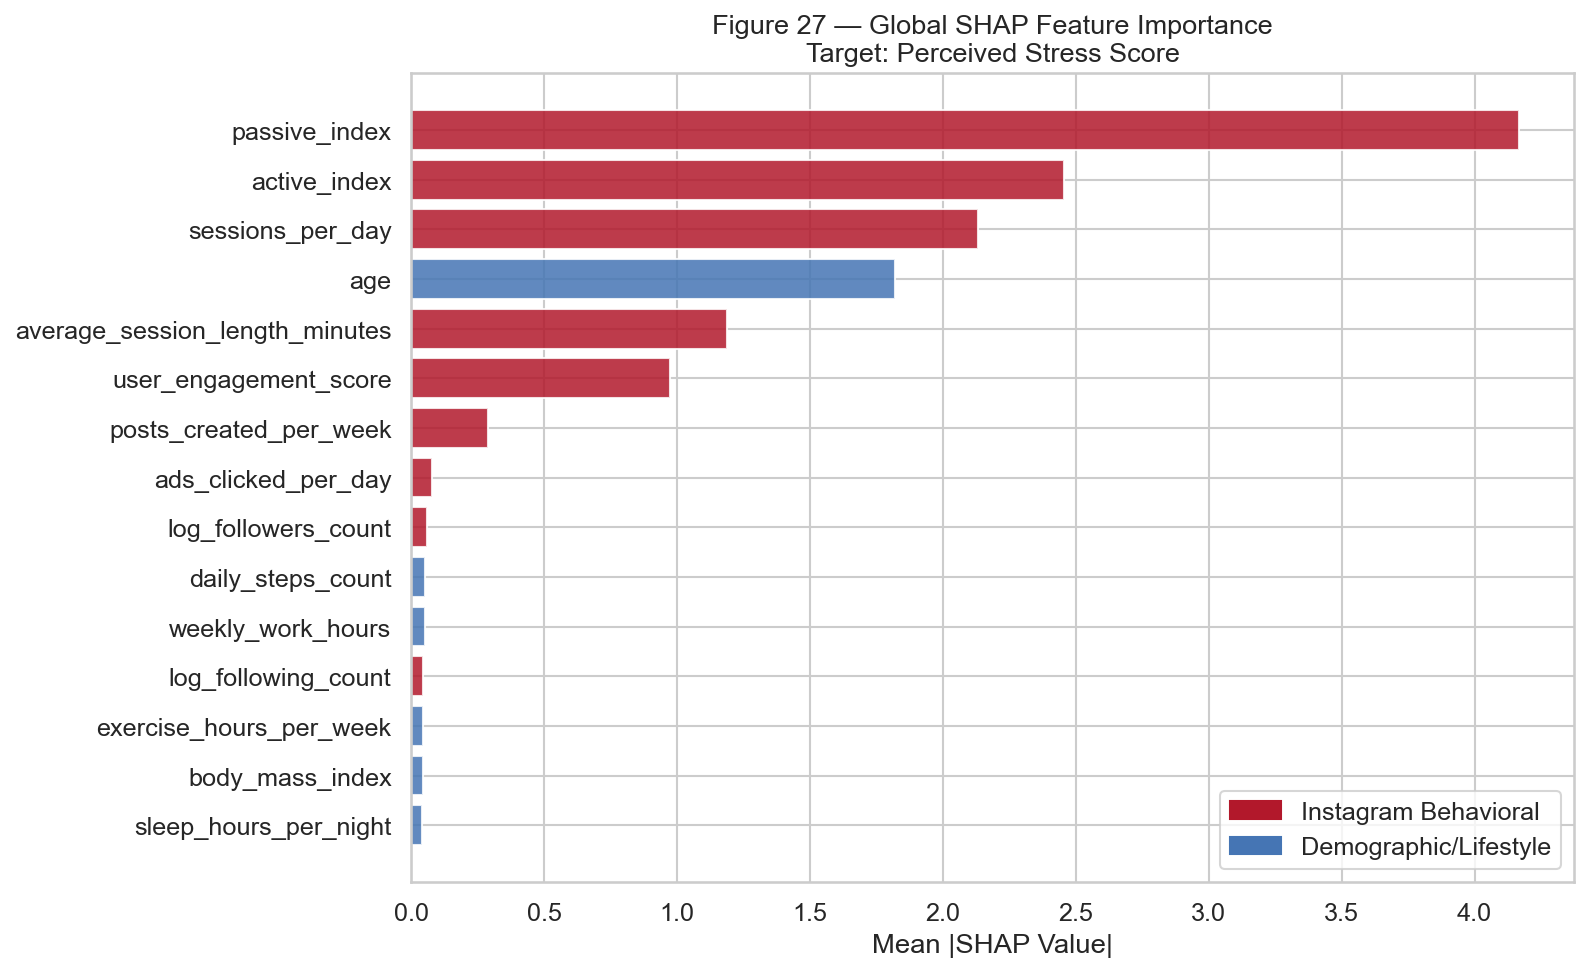

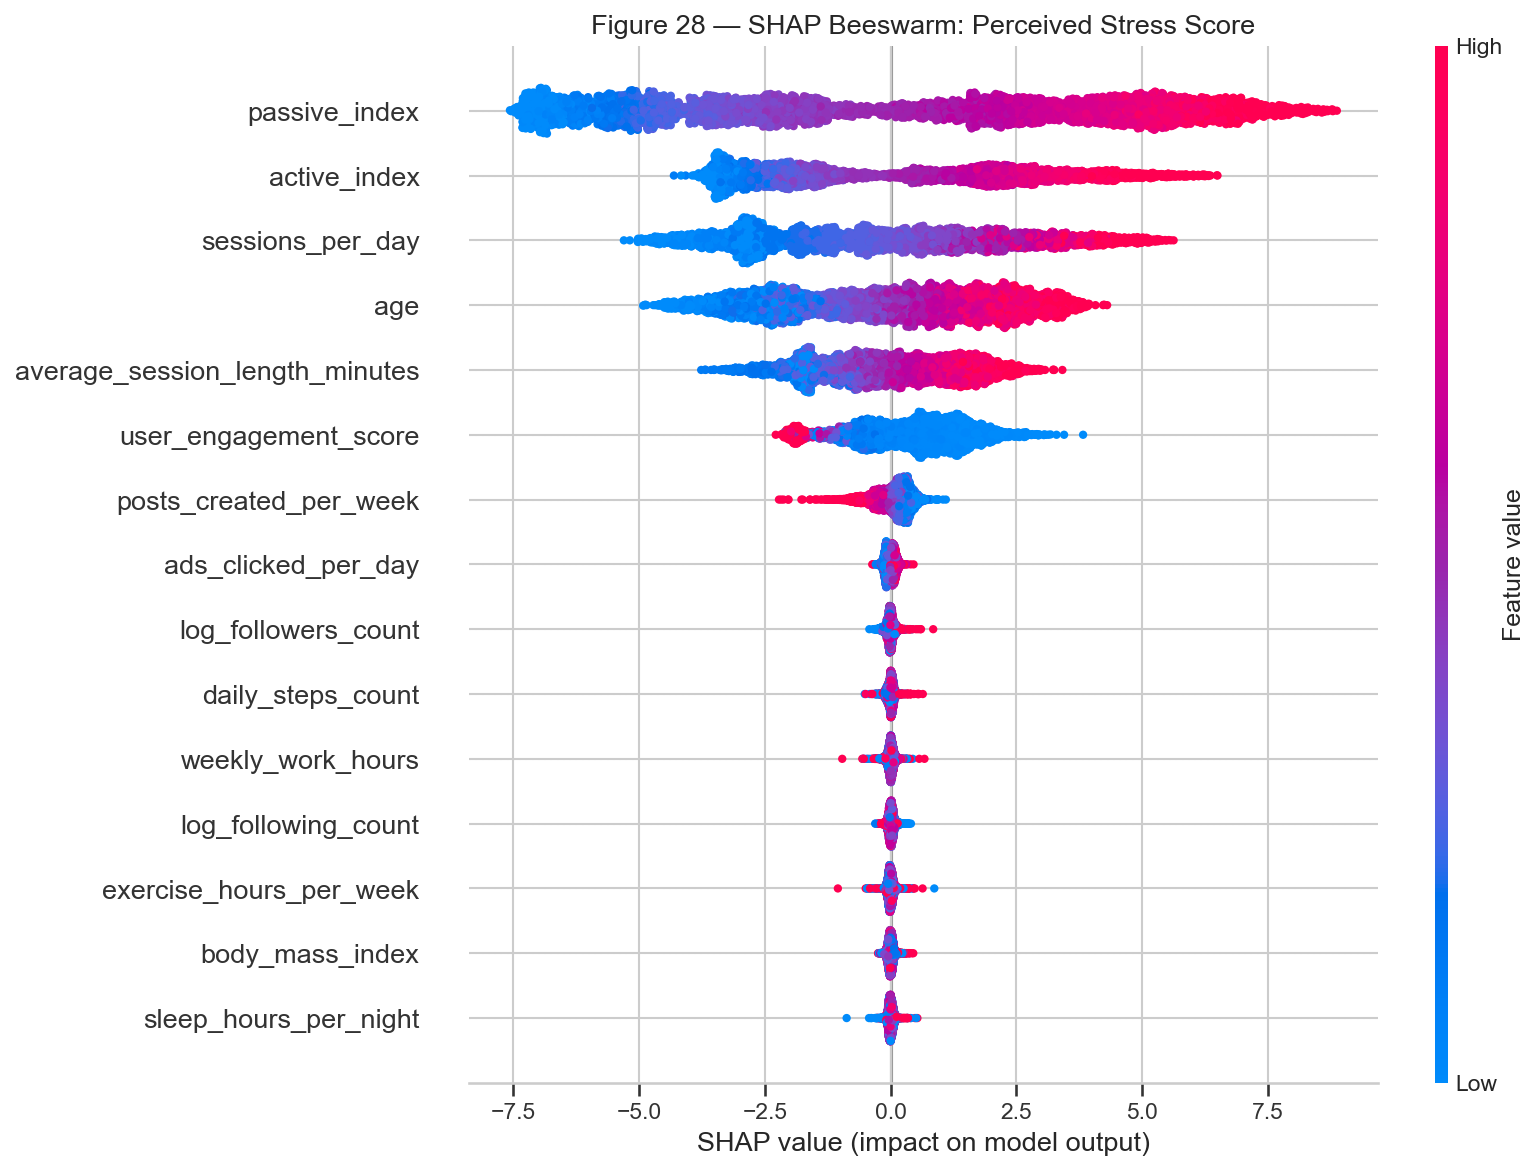

  [saved] fig28_shap_beeswarm_stress.png
    SHAP for self_reported_happiness ...


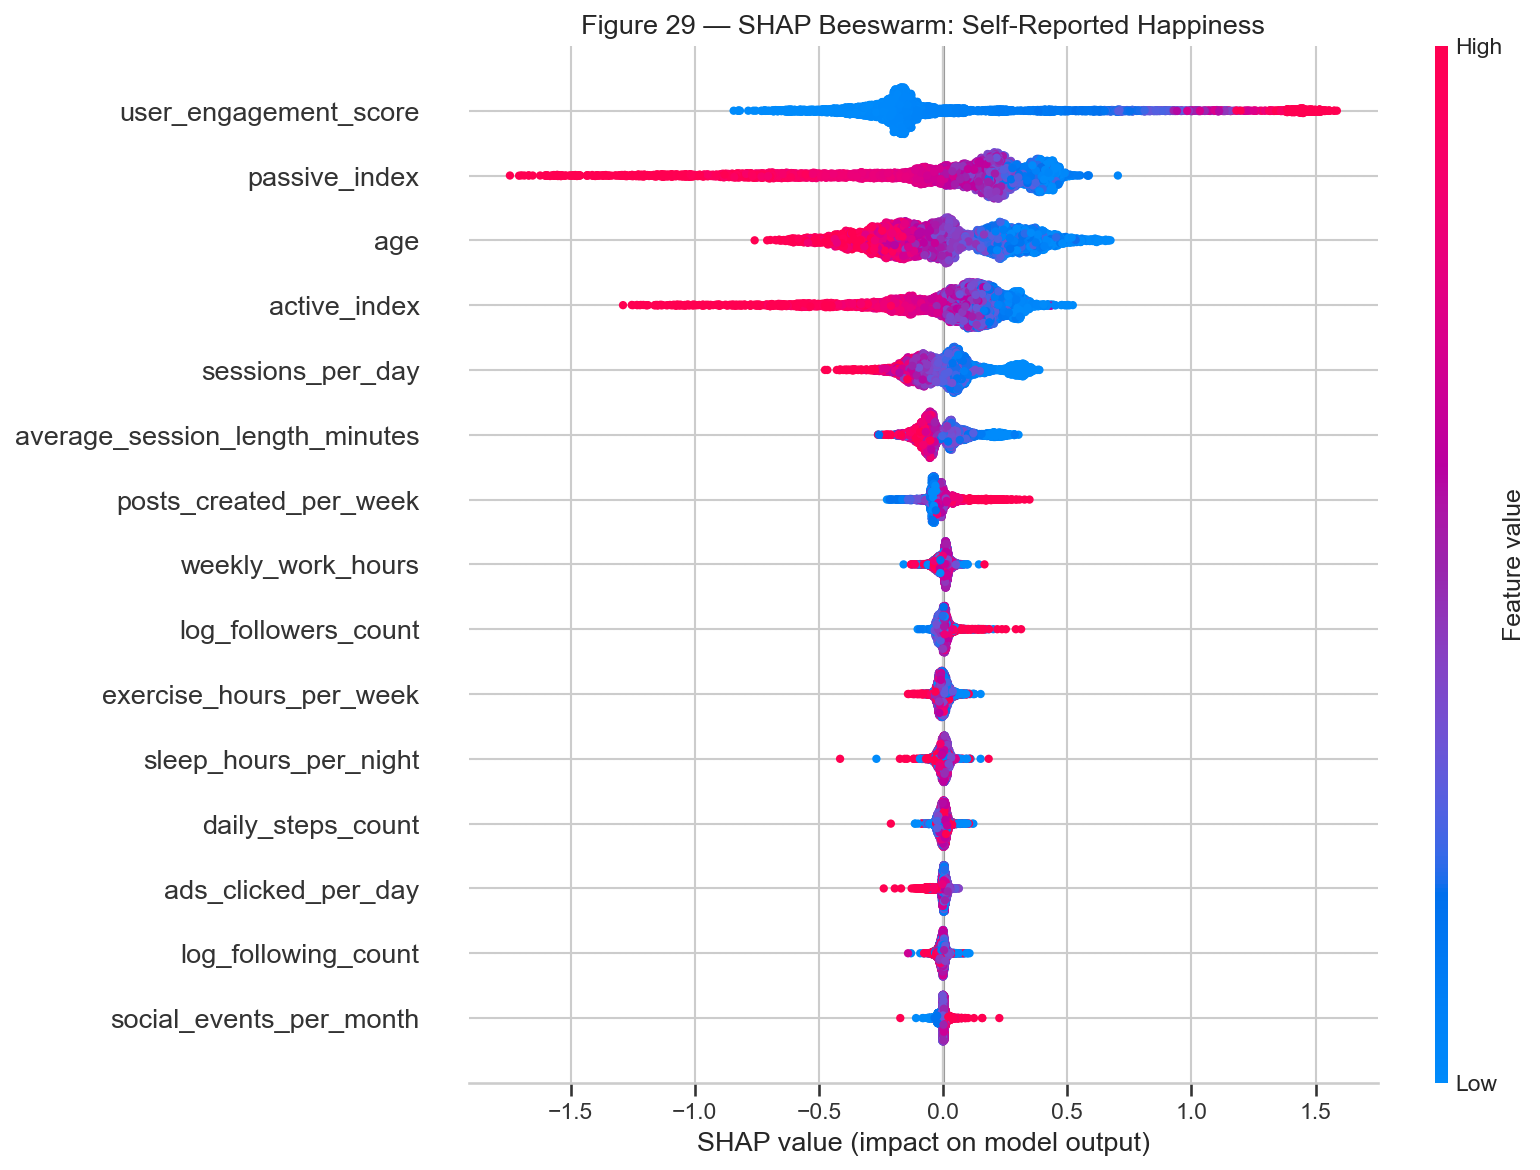

  [saved] fig29_shap_beeswarm_happiness.png
    SHAP dependence plots ...


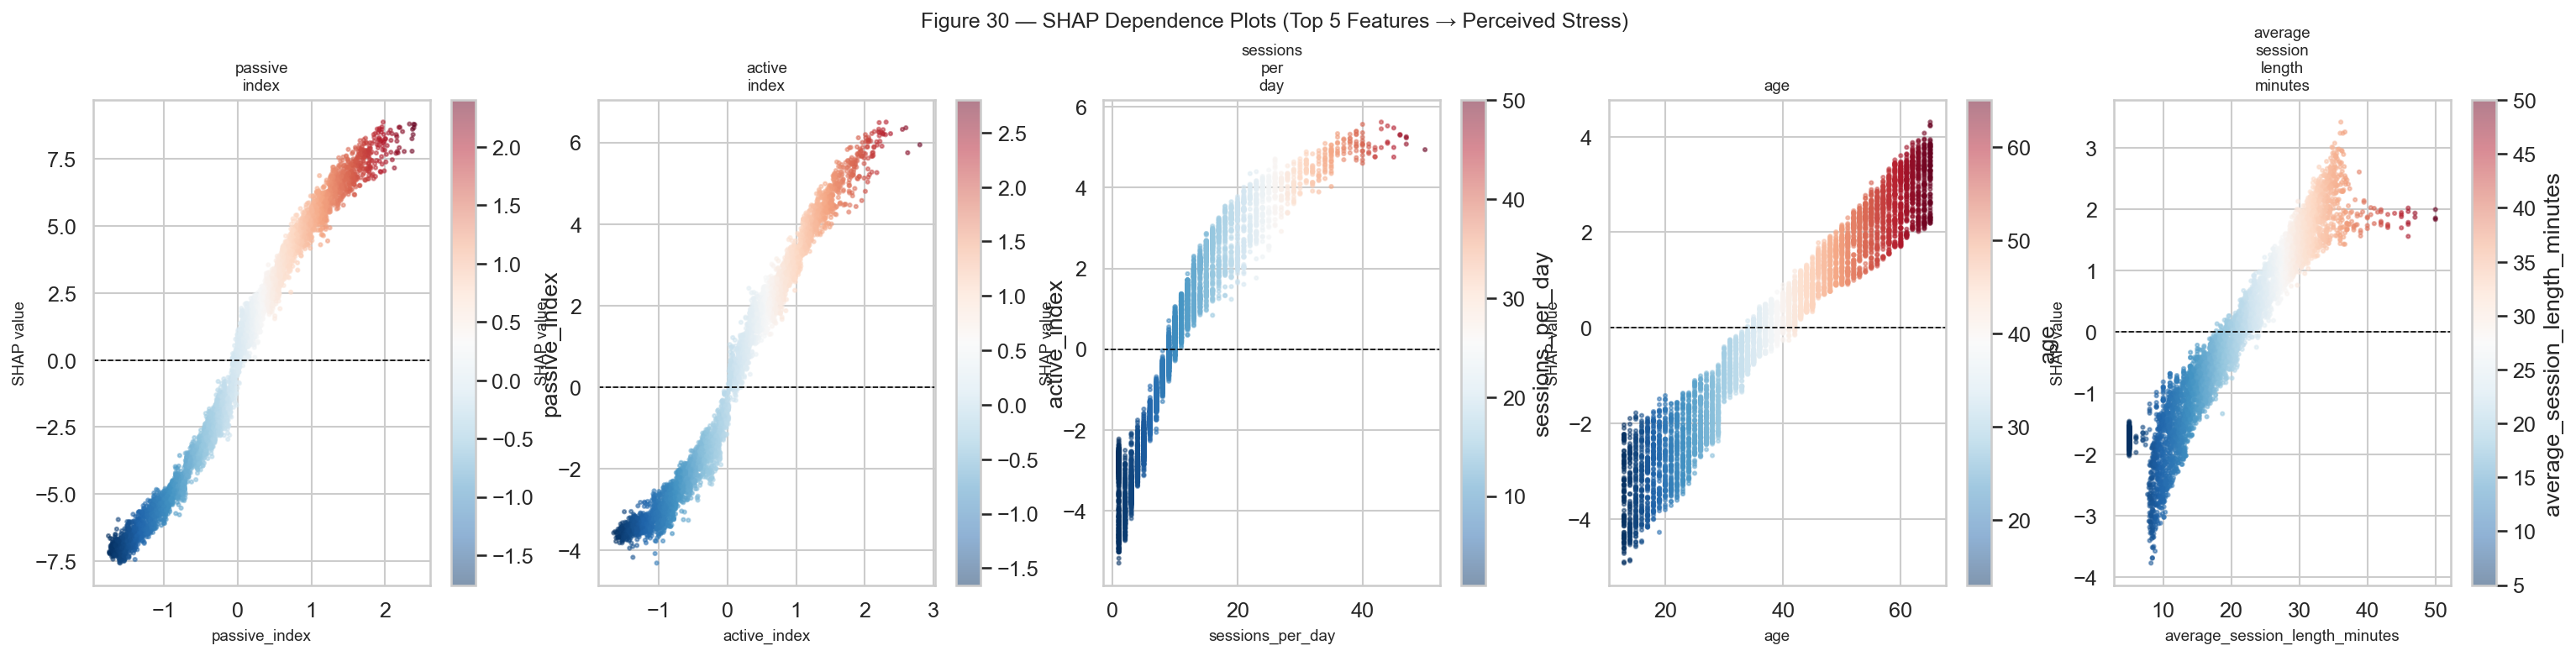

In [9]:
# Use XGBoost as base (consistent with best/near-best results)
best_target = "perceived_stress_score"
y_tr = df_model.loc[idx_train, best_target].values
y_te = df_model.loc[idx_test,  best_target].values

print(f"    Fitting XGBoost for SHAP on {best_target} ...")
xgb_shap = xgb.XGBRegressor(
    n_estimators=xgb_mod.best_iteration or 200,
    learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_shap.fit(X_train, y_tr)

# Compute SHAP on test set (subsample 5000 for speed)
SHAP_N = min(5000, len(X_test))
X_shap = X_test.iloc[:SHAP_N].reset_index(drop=True)
explainer   = shap.TreeExplainer(xgb_shap)
shap_values = explainer.shap_values(X_shap)

shap_df = pd.DataFrame(shap_values, columns=FEATURE_COLS)
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)
# mean_abs_shap.to_csv(os.path.join(OUT_DIR, "table3_shap_importance_stress.csv"))
print(f"\n    Top 10 SHAP features (mean |SHAP|):")
print(mean_abs_shap.head(10).round(4).to_string())

#  SHAP bar plot (global importance) 
fig, ax = plt.subplots(figsize=(10, 7))
top_feat = mean_abs_shap.head(15)
colors = ["#b2182b" if f in ["passive_index","active_index","sessions_per_day",
          "average_session_length_minutes","notification_response_rate",
          "ads_clicked_per_day","posts_created_per_week",
          "user_engagement_score","log_followers_count","log_following_count"]
          else "#4575b4" for f in top_feat.index]
ax.barh(top_feat.index[::-1], top_feat.values[::-1], color=colors[::-1], alpha=0.85)
ax.set_xlabel("Mean |SHAP Value|")
ax.set_title(f"Figure 27 — Global SHAP Feature Importance\nTarget: {best_target.replace('_',' ').title()}")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#b2182b",label="Instagram Behavioral"),
                   Patch(color="#4575b4",label="Demographic/Lifestyle")],
          loc="lower right")

#  SHAP beeswarm 
print("    Generating SHAP beeswarm ...")
fig, ax = plt.subplots(figsize=(11, 8))
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_COLS,
                  max_display=15, show=False, plot_size=None)
plt.title(f"Figure 28 — SHAP Beeswarm: {best_target.replace('_',' ').title()}", fontsize=13)
plt.tight_layout()
plt.show()
print("  [saved] fig28_shap_beeswarm_stress.png")

# SHAP beeswarm for happiness
print("    SHAP for self_reported_happiness ...")
y_tr_h = df_model.loc[idx_train, "self_reported_happiness"].values
xgb_shap_h = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6,
                                subsample=0.8, colsample_bytree=0.8,
                                random_state=42, n_jobs=-1, verbosity=0)
xgb_shap_h.fit(X_train, y_tr_h)
explainer_h   = shap.TreeExplainer(xgb_shap_h)
shap_values_h = explainer_h.shap_values(X_shap)

fig, ax = plt.subplots(figsize=(11, 8))
shap.summary_plot(shap_values_h, X_shap, feature_names=FEATURE_COLS,
                  max_display=15, show=False, plot_size=None)
plt.title("Figure 29 — SHAP Beeswarm: Self-Reported Happiness", fontsize=13)
plt.tight_layout()
plt.show()
print("  [saved] fig29_shap_beeswarm_happiness.png")

#  SHAP dependence plots 
print("    SHAP dependence plots ...")
top5_feats = list(mean_abs_shap.head(5).index)
fig, axes = plt.subplots(1, len(top5_feats), figsize=(5*len(top5_feats), 5))
if len(top5_feats) == 1:
    axes = [axes]
for ax, feat in zip(axes, top5_feats):
    feat_idx = list(FEATURE_COLS).index(feat)
    shap_col  = shap_df[feat].values
    feat_vals = X_shap[feat].values
    sc = ax.scatter(feat_vals, shap_col, c=feat_vals,
                    cmap="RdBu_r", s=4, alpha=0.5, rasterized=True)
    plt.colorbar(sc, ax=ax, label=feat)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel("SHAP value", fontsize=9)
    ax.set_title(feat.replace("_","\n"), fontsize=9)

plt.suptitle("Figure 30 — SHAP Dependence Plots (Top 5 Features → Perceived Stress)",
             fontsize=12, y=1.02)
plt.show()

Lasso Feature Selection

Text(0.5, 1.02, 'Figure 32 — LASSO Coefficient Paths (Cross-Validated alpha)\nNon-zero = Selected Features')

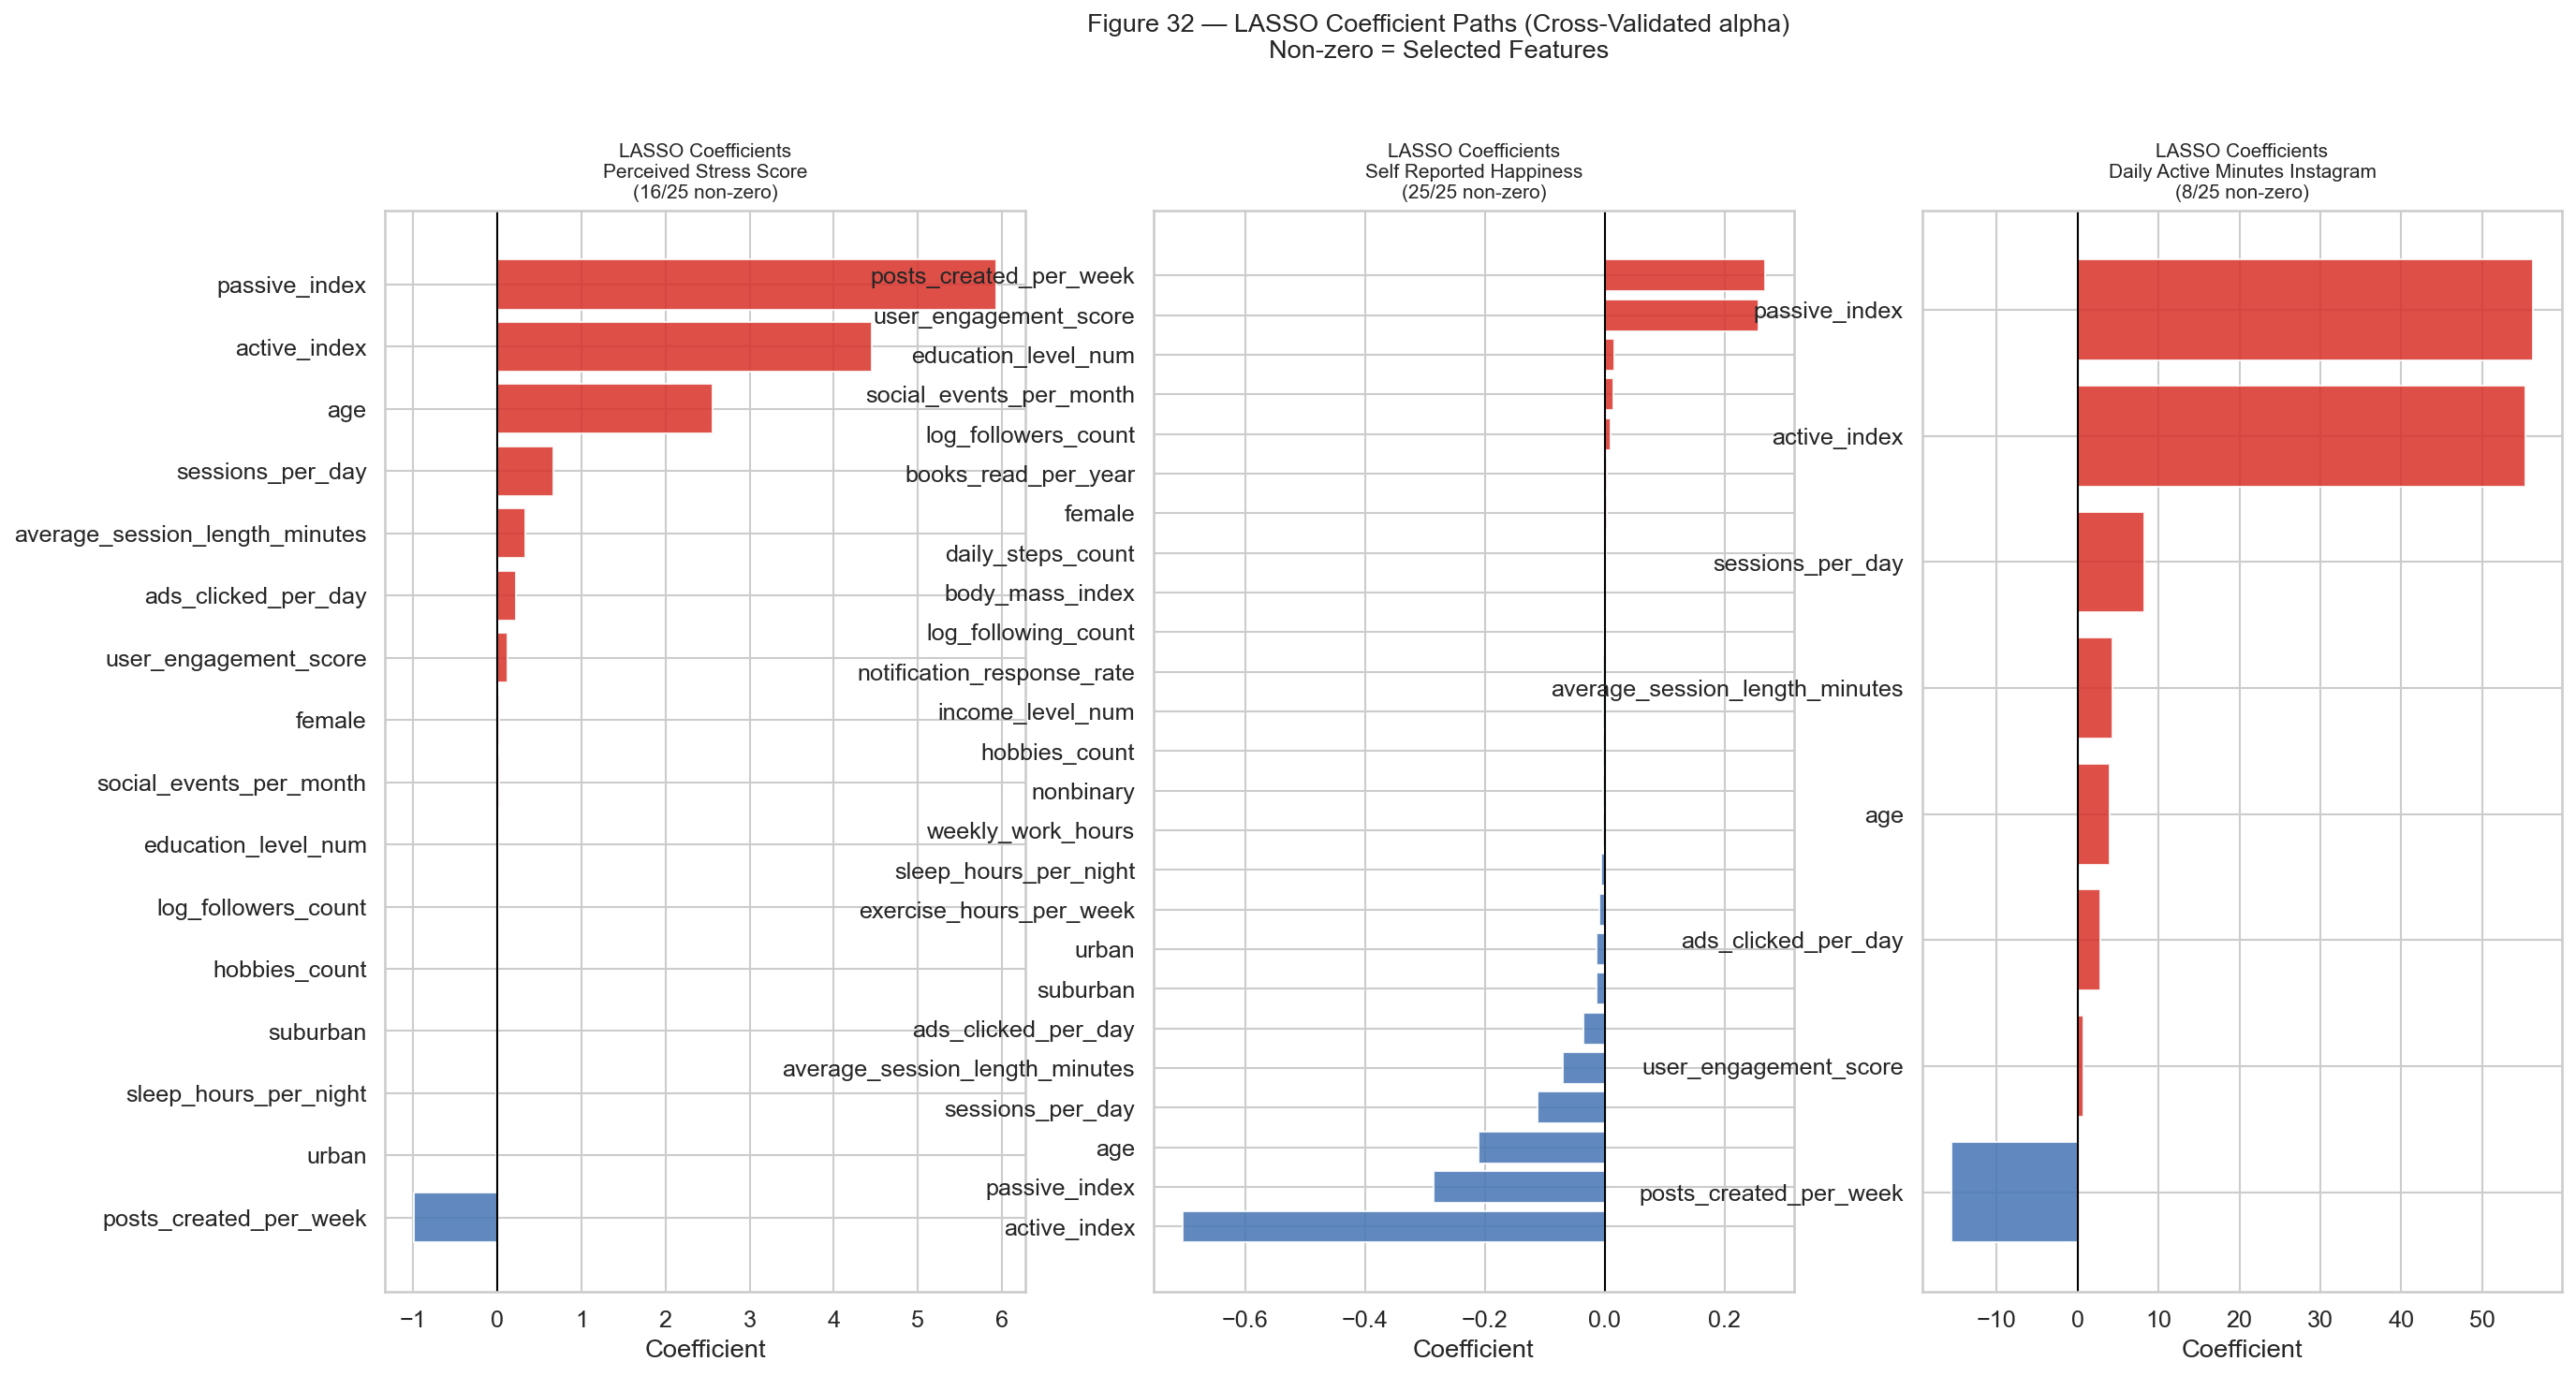

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
for ax, target in zip(axes, list(TARGETS.keys())):
    y_tr = df_model.loc[idx_train, target].values
    lasso_sel = LassoCV(cv=5, max_iter=5000, n_jobs=-1, random_state=42)
    lasso_sel.fit(X_train_sc, y_tr)
    coefs = pd.Series(lasso_sel.coef_, index=FEATURE_COLS)
    nonzero = coefs[coefs.abs() > 1e-6].sort_values()
    colors = ["#d73027" if v > 0 else "#4575b4" for v in nonzero]
    ax.barh(nonzero.index, nonzero.values, color=colors, alpha=0.85)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"LASSO Coefficients\n{target.replace('_',' ').title()}\n"
                 f"({len(nonzero)}/{len(FEATURE_COLS)} non-zero)", fontsize=10)
    ax.set_xlabel("Coefficient")

plt.suptitle("Figure 32 — LASSO Coefficient Paths (Cross-Validated alpha)\nNon-zero = Selected Features",
             fontsize=13, y=1.02)

Learning Curves

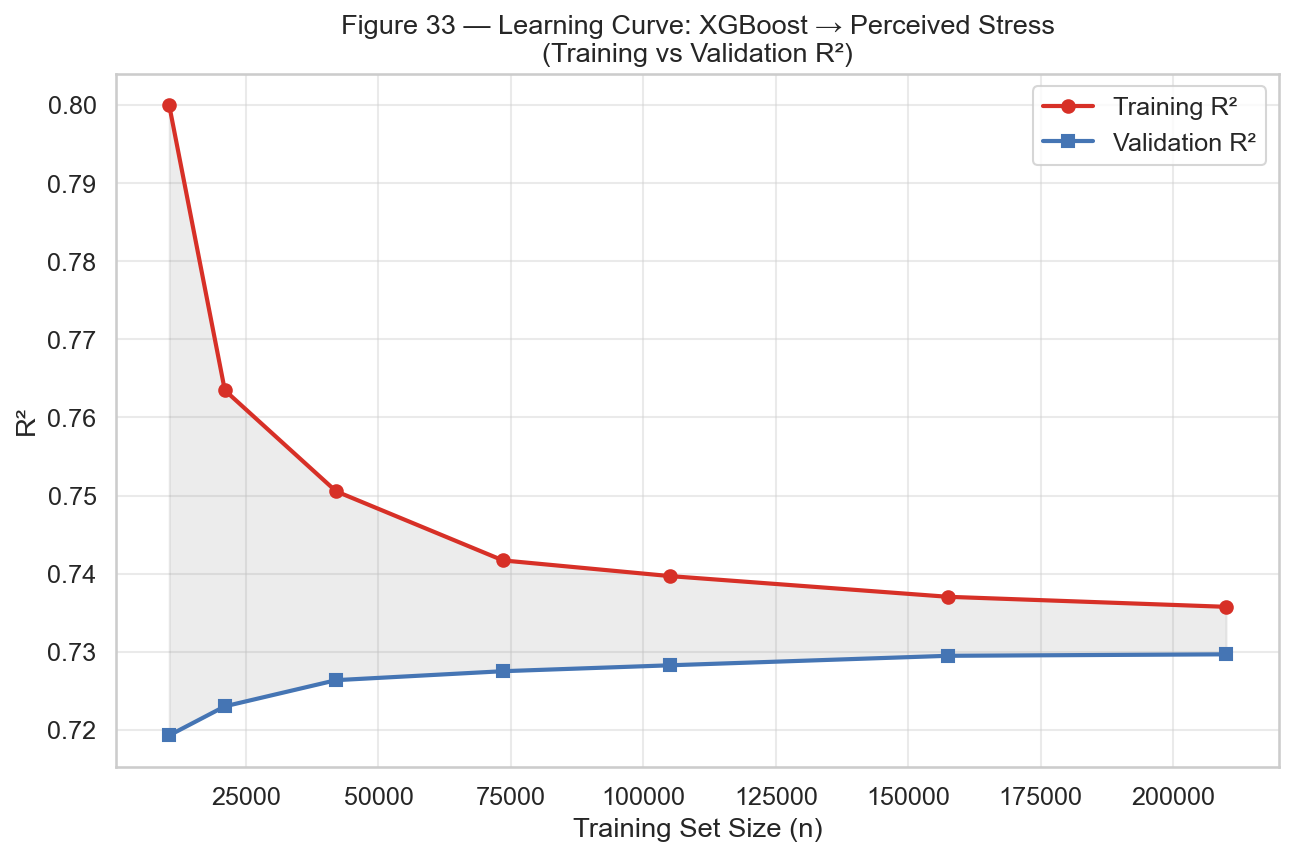

In [11]:
y_tr_lc = df_model.loc[idx_train, "perceived_stress_score"].values
y_vl_lc = df_model.loc[idx_val,   "perceived_stress_score"].values

train_sizes = [0.05, 0.10, 0.20, 0.35, 0.50, 0.75, 1.0]
train_r2s, val_r2s, train_ns = [], [], []

for frac in train_sizes:
    n = max(100, int(frac * len(X_train)))
    idx_sub = np.random.choice(len(X_train), n, replace=False)
    X_sub = X_train.iloc[idx_sub]
    y_sub = y_tr_lc[idx_sub]

    xgb_lc = xgb.XGBRegressor(
        n_estimators=100, learning_rate=0.1, max_depth=5,
        subsample=0.8, random_state=42, n_jobs=-1, verbosity=0
    )
    xgb_lc.fit(X_sub, y_sub, verbose=False)
    train_r2s.append(r2_score(y_sub, xgb_lc.predict(X_sub)))
    val_r2s.append(r2_score(y_vl_lc, xgb_lc.predict(X_val)))
    train_ns.append(n)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_ns, train_r2s, "o-", color="#d73027", linewidth=2, label="Training R²")
ax.plot(train_ns, val_r2s,   "s-", color="#4575b4", linewidth=2, label="Validation R²")
ax.fill_between(train_ns, train_r2s, val_r2s, alpha=0.15, color="gray")
ax.set_xlabel("Training Set Size (n)")
ax.set_ylabel("R²")
ax.set_title("Figure 33 — Learning Curve: XGBoost → Perceived Stress\n(Training vs Validation R²)")
ax.legend()
ax.grid(True, alpha=0.4)

plt.show()

Residual Analysis

Text(0.5, 0.98, 'Figure 34 — XGBoost Residual Analysis: Perceived Stress Score')

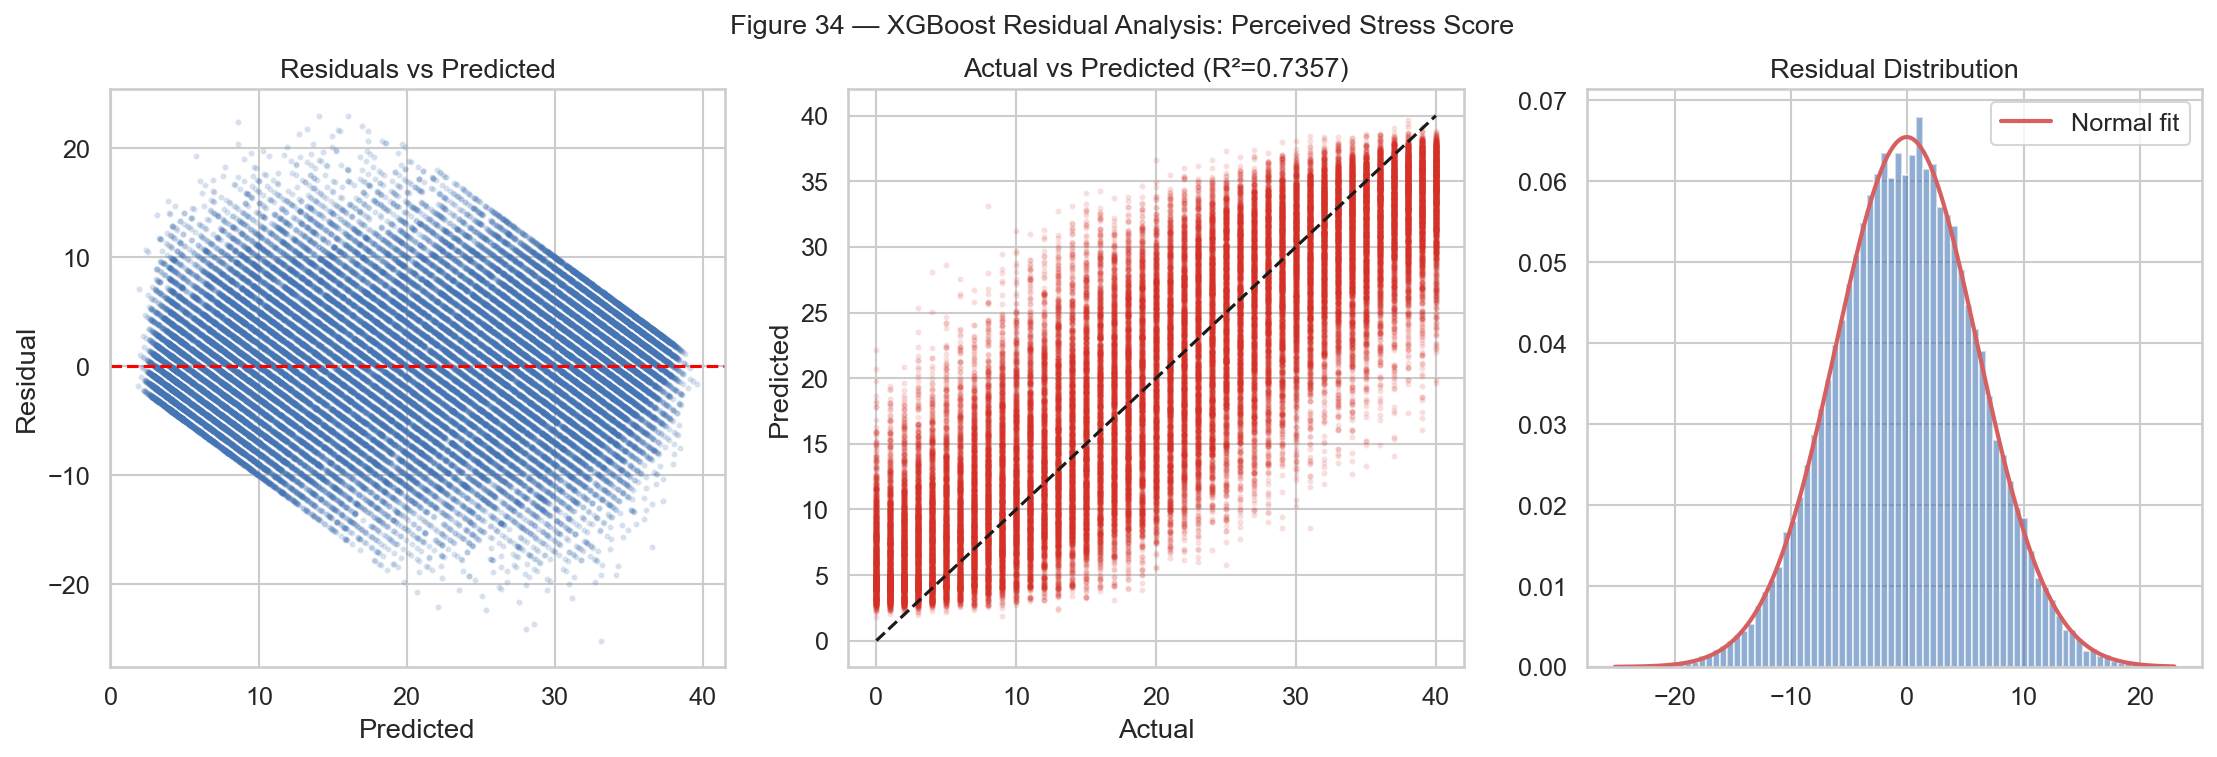

In [12]:
y_te_stress = df_model.loc[idx_test, "perceived_stress_score"].values
xgb_final = xgb.XGBRegressor(
    n_estimators=xgb_mod.best_iteration or 200,
    learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_final.fit(df_model.loc[idx_train, FEATURE_COLS],
              df_model.loc[idx_train, "perceived_stress_score"])
y_pred_final = xgb_final.predict(X_test)
residuals    = y_te_stress - y_pred_final

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(y_pred_final, residuals, alpha=0.15, s=4, color="#4575b4")
axes[0].axhline(0, color="red", linewidth=1.5, linestyle="--")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

axes[1].scatter(y_te_stress, y_pred_final, alpha=0.10, s=4, color="#d73027")
mn, mx = y_te_stress.min(), y_te_stress.max()
axes[1].plot([mn,mx],[mn,mx], "k--", linewidth=1.5)
axes[1].set_xlabel("Actual"); axes[1].set_ylabel("Predicted")
r2_show = r2_score(y_te_stress, y_pred_final)
axes[1].set_title(f"Actual vs Predicted (R²={r2_show:.4f})")

axes[2].hist(residuals, bins=80, density=True, color="#4575b4", alpha=0.6, edgecolor="white")
xr = np.linspace(residuals.min(), residuals.max(), 200)
axes[2].plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()),
             "r-", linewidth=2, label="Normal fit")
axes[2].set_title("Residual Distribution")
axes[2].legend()

plt.suptitle("Figure 34 — XGBoost Residual Analysis: Perceived Stress Score", fontsize=13)


Summary Table

In [13]:
print("\n" + "="*70)
print("PART 3 COMPLETE — Summary")
print("="*70)
print("\nRegression R² on test set:")
print(bench_df.pivot(index="model", columns="target", values="R2").round(4).to_string())
print("\nClassification (high_stress_binary):")
print(clf_tbl.to_string())
print("\nSHAP top features (perceived stress):")
print(mean_abs_shap.head(8).round(4).to_string())



PART 3 COMPLETE — Summary

Regression R² on test set:
target        daily_active_minutes_instagram  perceived_stress_score  self_reported_happiness
model                                                                                        
ElasticNet                            0.9819                  0.7195                   0.1502
LASSO                                 0.9822                  0.7195                   0.1502
LightGBM                              0.9978                  0.7354                   0.1630
OLS                                   0.9822                  0.7195                   0.1502
RandomForest                          0.9916                  0.7334                   0.1602
Ridge                                 0.9822                  0.7195                   0.1502
XGBoost                               0.9968                  0.7358                   0.1629

Classification (high_stress_binary):
                  AUC       AP       F1    Brier
LogisticReg 